In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier

from sklearn.preprocessing import KBinsDiscretizer

from sklearn.model_selection import train_test_split, validation_curve, GridSearchCV

from sklearn.metrics import ConfusionMatrixDisplay

from sklearn.metrics import accuracy_score as accuracy
from sklearn.metrics import precision_score as precision
from sklearn.metrics import recall_score as recall
from sklearn.metrics import f1_score as f1
from sklearn.metrics import log_loss

#SET RANDOM STATE

In [2]:
RANDOM_STATE = 42

#READ DATA

In [3]:
trainDF = pd.read_csv("../driving/train_motion_data.csv").dropna()
testDF = pd.read_csv("../driving/test_motion_data.csv").dropna()

#NO CROSS VALIDATIONS

In [4]:
# Select input and output features
X = trainDF.drop(columns=['Class'])
y = np.ravel(trainDF[['Class']])

In [5]:
# Initialize and fit random forest classifier
rfModel = RandomForestClassifier(random_state=RANDOM_STATE)
rfModel.fit(X, y)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [6]:
# Calculate prediction accuracy
testX = testDF.drop(columns=['Class'])
testy = np.ravel(testDF[['Class']])

pred = rfModel.predict(testX)

accuracy(testy, pred)

0.3232814526588846

#Using Cross Validation

##hyper parameters are:
n_estimators : int, default=100
criterion : {"gini", "entropy", "log_loss"}, default="gini"
max_depth : int, default=None
min_samples_split : int or float, default=2
min_samples_leaf : int or float, default=1
max_features : {"sqrt", "log2", None}, int or float, default="sqrt"
max_leaf_nodes : int, default=None
min_impurity_decrease : float, default=0.0
class_weight : {"balanced", "balanced_subsample"}, dict or list of dicts, default=None
ccp_alpha : non-negative float, default=0.0

##data

In [7]:
# using one big data set to get better results
df = pd.concat([trainDF, testDF], axis=0, join='outer')

all_X = df.drop(columns=['Class'])
all_y = np.ravel(df['Class'])

X, X_test, y, y_test = train_test_split(all_X, all_y, test_size=0.25, random_state=RANDOM_STATE)

In [8]:
# # Discretize X to hopefully predict data of continuous features better
# kbd = KBinsDiscretizer(n_bins=20, strategy='uniform')
# X = kbd.fit_transform(X)
# # this looked like it might help at a specific number of bins, however,
# # cross validation should be used to find the number of bins, and I'm not
# # sure how to implement cross validation in the preprocessing step

##plotting cross validation on hyper parameters

In [9]:
# get an idea of where hyper parameters should go

def plotValCurve(model, X, y, hParam:str, paramValues:list, cv:int, nJobs = None):
    """
    This code is inspired by the Applied Machine Learning (zyBook) chapter 5.3 but meant to be generalized
    to any hyper param
    """
    train_scores, test_scores = validation_curve(estimator=model,
                           X=X, y=y, 
                           param_name=hParam,
                           param_range=paramValues,
                           cv=cv,
                           n_jobs=nJobs)
    
    # Calculate mean and SD for training and testing
    train_scores_mean = np.mean(train_scores, axis=1)
    train_scores_std = np.std(train_scores, axis=1)
    test_scores_mean = np.mean(test_scores, axis=1)
    test_scores_std = np.std(test_scores, axis=1)
    
    sns.lineplot(x=paramValues, y=train_scores_mean, label='Training', color='#1f77b4')
    sns.lineplot(x=paramValues, y=test_scores_mean, label='Validation', color='#ff7f0e')
    plt.fill_between(paramValues, train_scores_mean-train_scores_std, train_scores_mean+train_scores_std, 
                    alpha=0.1, color='#1f77b4')
    plt.fill_between(paramValues, test_scores_mean-test_scores_std, test_scores_mean+test_scores_std, 
                    alpha=0.1, color='#ff7f0e')

    plt.xlabel(hParam, fontsize=16)
    plt.ylabel('Score', fontsize=16)

## v0

In [10]:
defaultModel = RandomForestClassifier(random_state=RANDOM_STATE)
cv = 5
nJobs = -1 #-1 will use all available cores

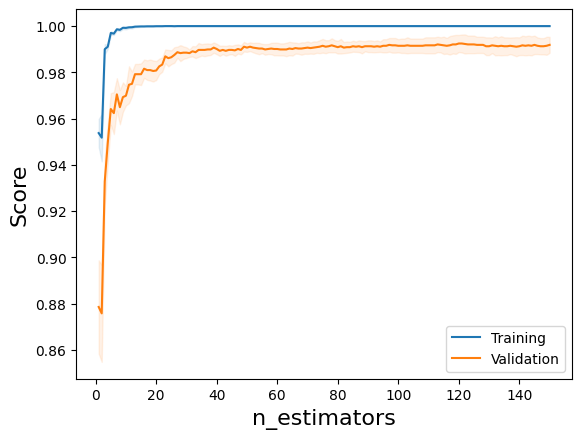

In [11]:
plotValCurve(defaultModel, X, y, 'n_estimators', list(range(1, 150+1)), cv, nJobs)
# seems like we should leave estimators the same

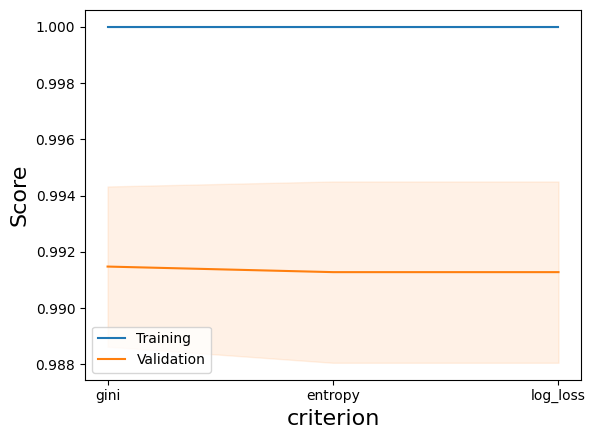

In [12]:
plotValCurve(defaultModel, X, y, 'criterion', ["gini", "entropy", "log_loss"], cv, nJobs)
# doesn't seem like criterion changes score

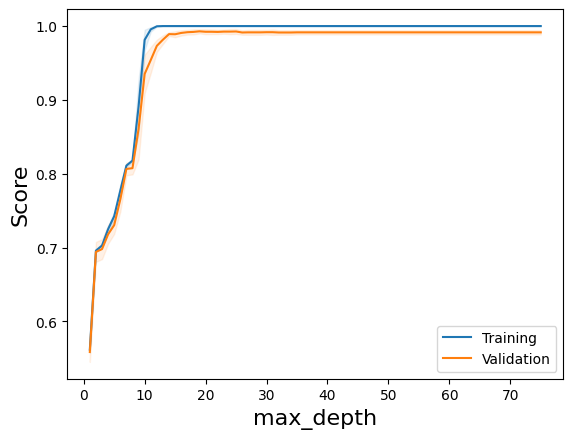

In [13]:
plotValCurve(defaultModel, X, y, 'max_depth', list(range(1, 75+1)), cv, nJobs)
# seems like max depth could be anything after 15

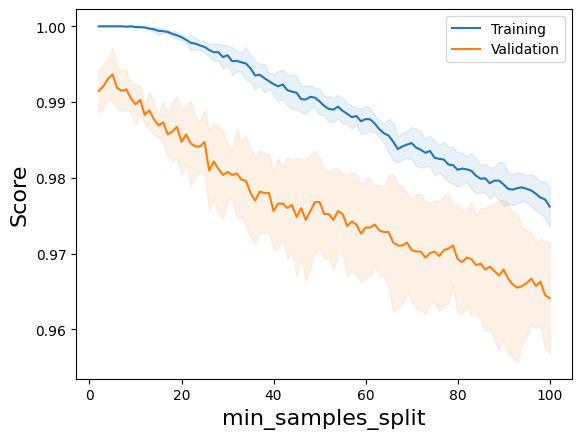

In [14]:
plotValCurve(defaultModel, X, y, 'min_samples_split', list(range(2, 100+1)), cv, nJobs)

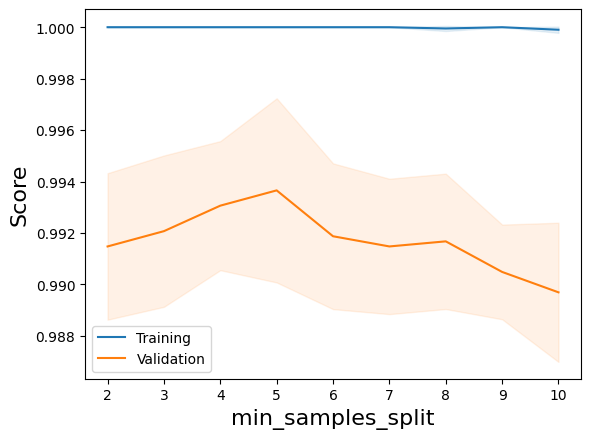

In [15]:
plotValCurve(defaultModel, X, y, 'min_samples_split', list(range(2, 10+1)), cv, nJobs)

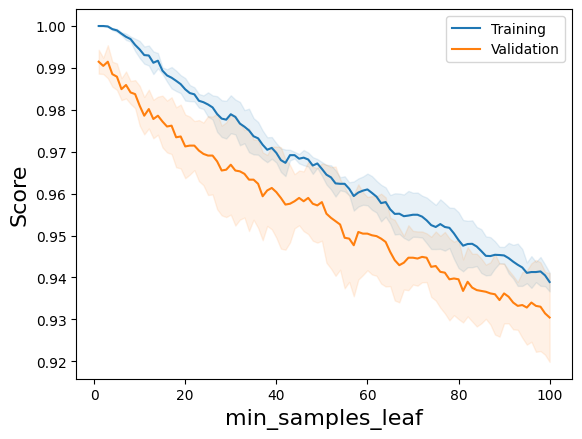

In [16]:
plotValCurve(defaultModel, X, y, 'min_samples_leaf', list(range(1, 100+1)), cv, nJobs)

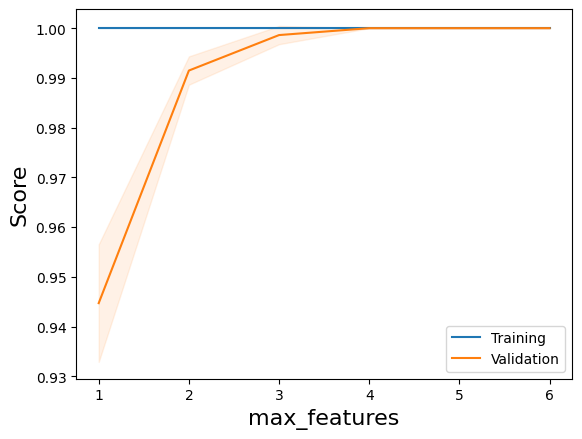

In [17]:
plotValCurve(defaultModel, X, y, 'max_features', list(range(1, 7)), cv, nJobs)

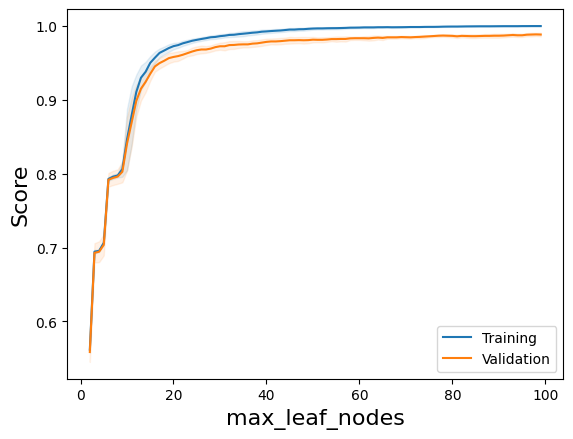

In [18]:
plotValCurve(defaultModel, X, y, 'max_leaf_nodes', list(range(2, 100)), cv, nJobs)

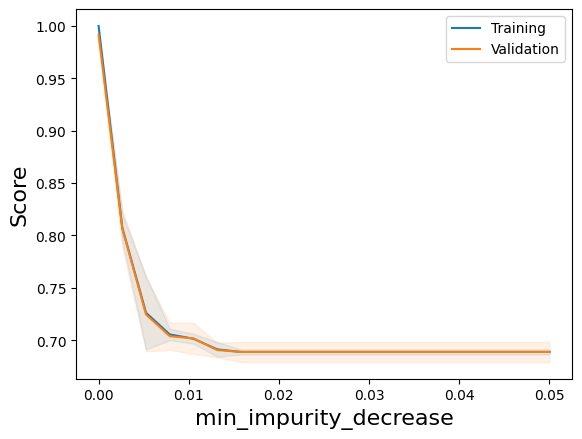

In [19]:
plotValCurve(defaultModel, X, y, 'min_impurity_decrease', list(np.linspace(0.0, .05, 20)), cv, nJobs)

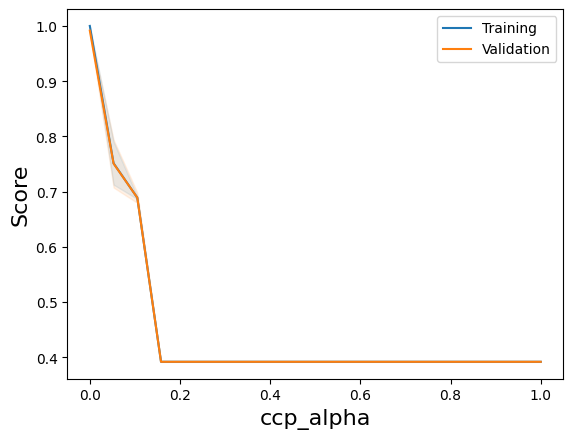

In [20]:
plotValCurve(defaultModel, X, y, 'ccp_alpha', list(np.linspace(0.0, 1, 20)), cv, nJobs)

## now that we've looked for the right ranges of hyper params lets do a grid search to make V1

In [21]:
newBaseModel = RandomForestClassifier(random_state=RANDOM_STATE)
rfModelTunner = GridSearchCV(newBaseModel,
                          {'min_samples_split':list(range(2, 8+1)),
                           'max_features': list(range(2, 7+1)),
                           'min_samples_leaf':list(range(1, 10+1))},
                          n_jobs=nJobs,
                          cv=cv)
rfModelTunner.fit(X, y)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_features': [2, 3, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 3, ...]}"
,scoring,None
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [22]:
cv_rfModel = rfModelTunner.best_estimator_
print(rfModelTunner.best_params_)

{'max_features': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}


## Testing v1

### just testing data

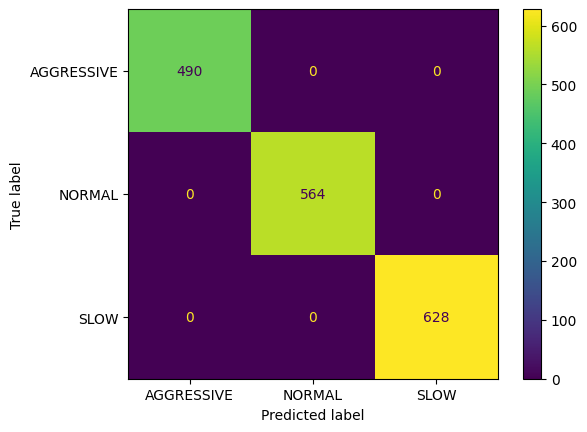

In [23]:
ConfusionMatrixDisplay.from_estimator(cv_rfModel, X_test, y_test)

In [24]:
pred = cv_rfModel.predict(X_test)

print('accuracy: ', accuracy(y_test, pred))
print('precision: ', precision(y_test, pred, average=None))
print('recall', recall(y_test, pred, average=None))
print('f1', f1(y_test, pred, average=None))

pred_proba = cv_rfModel.predict_proba(X_test)
print('loss', log_loss(y_test, pred_proba))

print('len: ', len(y_test))
print('pred: ', pred)
print('true: ', y_test)

accuracy:  1.0
precision:  [1. 1. 1.]
recall [1. 1. 1.]
f1 [1. 1. 1.]
loss 0.012402743658049132
len:  1682
pred:  ['NORMAL' 'NORMAL' 'NORMAL' ... 'AGGRESSIVE' 'AGGRESSIVE' 'SLOW']
true:  ['NORMAL' 'NORMAL' 'NORMAL' ... 'AGGRESSIVE' 'AGGRESSIVE' 'SLOW']


### All of the data

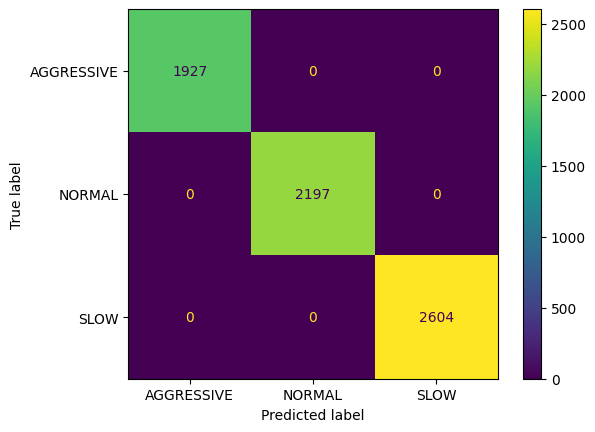

In [25]:
ConfusionMatrixDisplay.from_estimator(cv_rfModel, all_X, all_y)

In [26]:
all_pred = cv_rfModel.predict(all_X)

print('accuracy: ', accuracy(all_y, all_pred))
print('precision: ', precision(all_y, all_pred, average=None))
print('recall', recall(all_y, all_pred, average=None))
print('f1', f1(all_y, all_pred, average=None))

all_pred_proba = cv_rfModel.predict_proba(all_X)
print('loss', log_loss(all_y, all_pred_proba))

print('len: ', len(all_y))
print('pred: ', all_pred)
print('true: ', all_y)

accuracy:  1.0
precision:  [1. 1. 1.]
recall [1. 1. 1.]
f1 [1. 1. 1.]
loss 0.005983585554067407
len:  6728
pred:  ['NORMAL' 'NORMAL' 'NORMAL' ... 'SLOW' 'SLOW' 'SLOW']
true:  ['NORMAL' 'NORMAL' 'NORMAL' ... 'SLOW' 'SLOW' 'SLOW']


In [27]:
print()